# Plot TRPO Training Results

In [1]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

%matplotlib inline

In [2]:
log_dir = 'runs/trpo/20260304_234405'
log_dir = 'runs/trpo/20260305_015931'
event_acc = EventAccumulator(log_dir)
event_acc.Reload()

tags = event_acc.Tags()['scalars']
print(f"Found tags: {tags}")

Found tags: ['train/mean_return', 'train/mean_steps', 'train/surrogate_loss', 'train/kl_divergence', 'train/adv_abs_mean', 'train/adv_std']


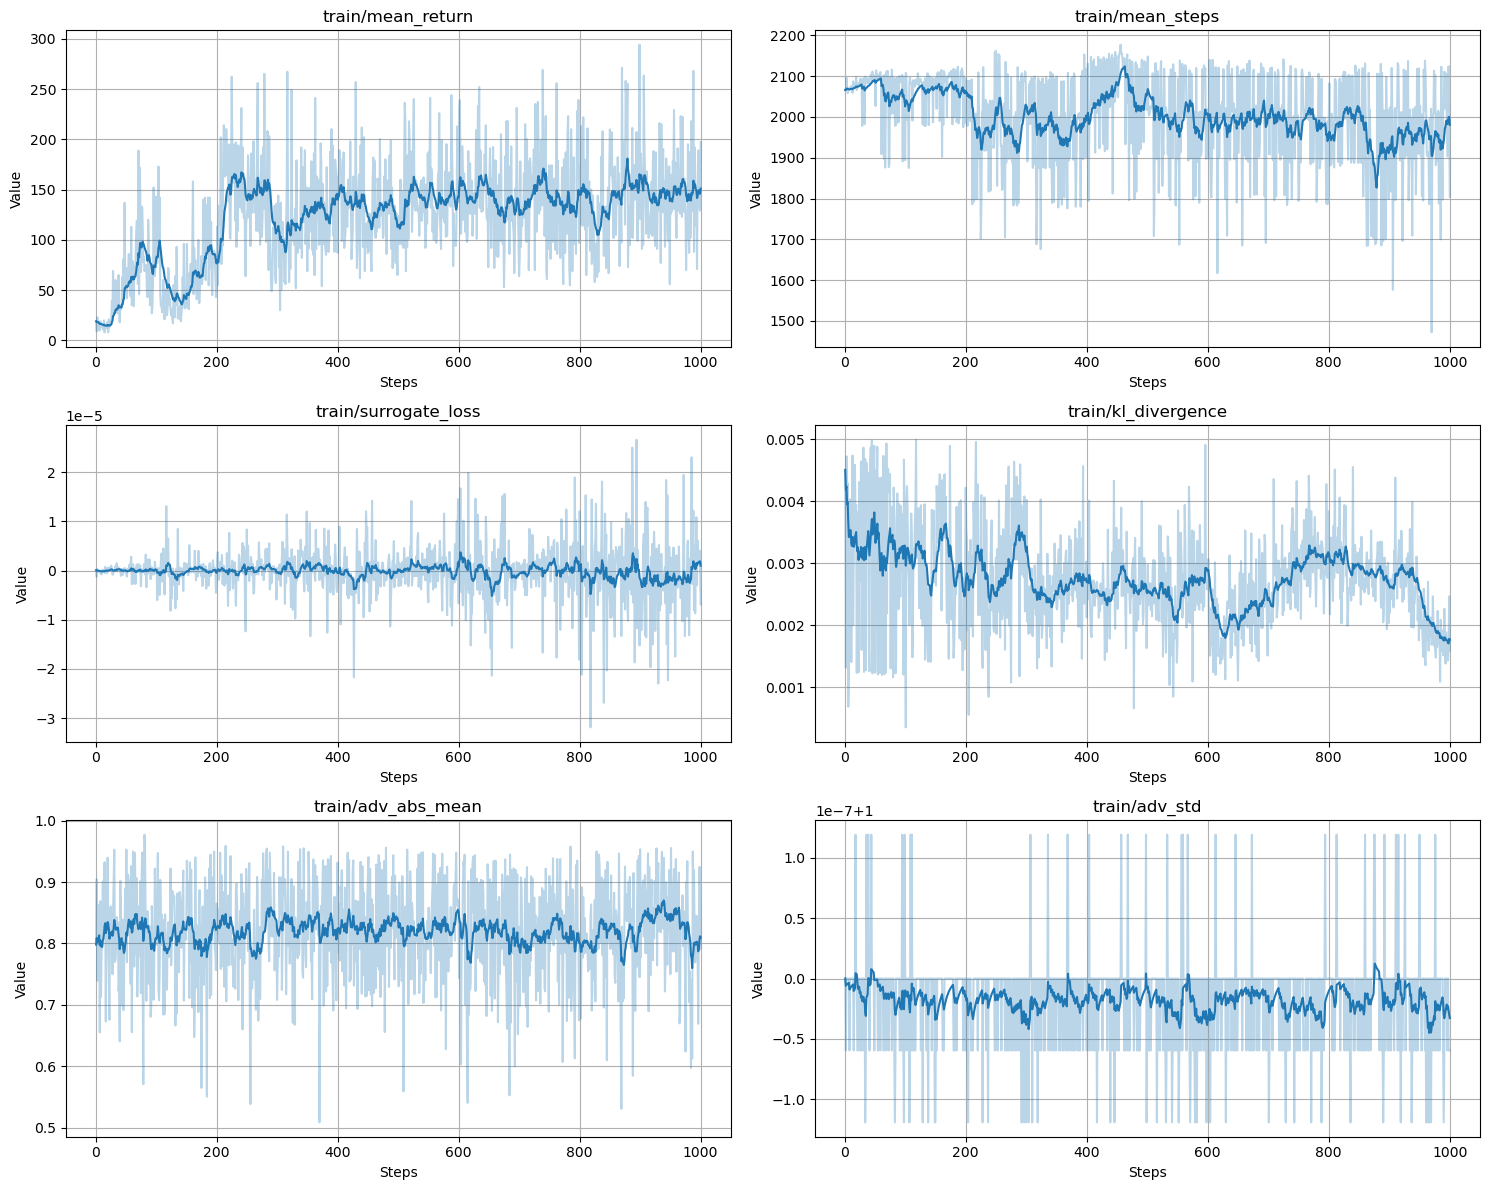

In [3]:
if tags:
    n_tags = len(tags)
    cols = 2
    rows = (n_tags + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    if n_tags == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, tag in enumerate(tags):
        events = event_acc.Scalars(tag)
        steps = [e.step for e in events]
        values = [e.value for e in events]
        
        ax = axes[i]
        alpha = 0.9
        smoothed_values = []
        if values:
            last = values[0]
            for v in values:
                smoothed_val = last * alpha + (1 - alpha) * v
                smoothed_values.append(smoothed_val)
                last = smoothed_val
        
        line, = ax.plot(steps, values, alpha=0.3)
        ax.plot(steps, smoothed_values, color=line.get_color())
        ax.set_title(tag)
        ax.set_xlabel("Steps")
        ax.set_ylabel("Value")
        ax.grid(True)
        
    # Hide any unused subplots
    for j in range(len(tags), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()
else:
    print("No scalar tags found.")

In [4]:
# checkpoints/policy_trpo_ep1000_gamma0.999_lr1e-03.pt

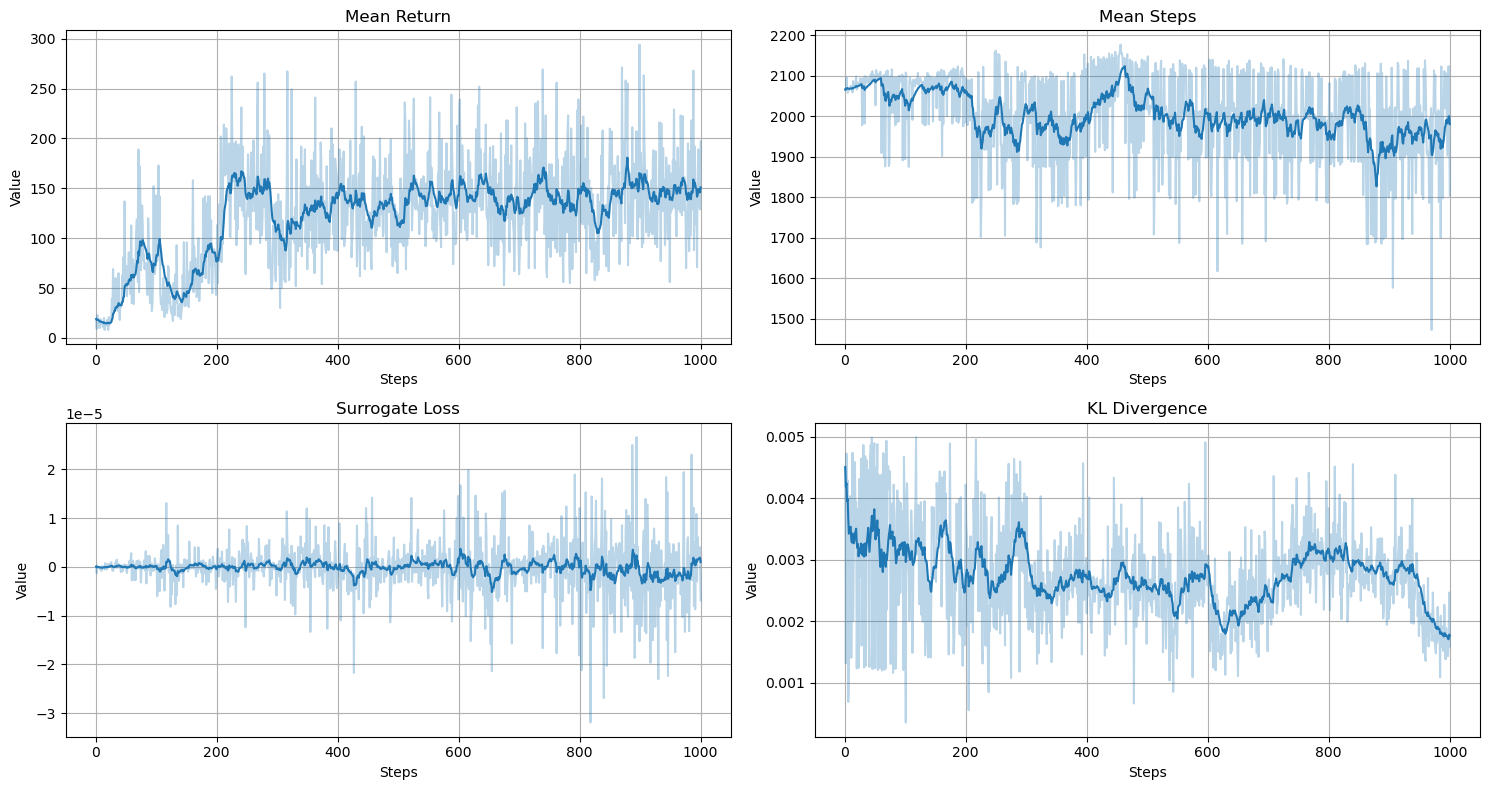

In [6]:
import os
import matplotlib.pyplot as plt

target_metrics = ["train/mean_return", "train/mean_steps", "train/kl_divergence", "train/surrogate_loss"]

# Map internal tag names to readable titles explicitly
title_mapping = {
    "train/mean_return": "Mean Return",
    "train/mean_steps": "Mean Steps",
    "train/kl_divergence": "KL Divergence",
    "train/surrogate_loss": "Surrogate Loss"
}

tags = [tag for tag in tags if tag in target_metrics]
n_tags = len(tags)
cols = 2
rows = (n_tags + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))

# Because cols=2, `axes` is ALWAYS a NumPy array (at least 1x2)
axes = axes.flatten()
    
for i, tag in enumerate(tags):
    events = event_acc.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    
    ax = axes[i]
    alpha = 0.9
    smoothed_values = []
    if values:
        last = values[0]
        for v in values:
            smoothed_val = last * alpha + (1 - alpha) * v
            smoothed_values.append(smoothed_val)
            last = smoothed_val
    
    line, = ax.plot(steps, values, alpha=0.3)
    ax.plot(steps, smoothed_values, color=line.get_color())
    
    # Use the readable title from mapping, fallback to a capitalized string if not found
    readable_title = title_mapping.get(tag, tag.replace('_', ' ').replace('/', ' ').title())
    ax.set_title(readable_title)
    
    ax.set_xlabel("Steps")
    ax.set_ylabel("Value")
    ax.grid(True)
    
# Hide any unused subplots
for j in range(len(tags), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()

# ----------------- WHAT CHANGED -----------------
# Ensure the 'assets' directory exists safely without errors
os.makedirs("assets", exist_ok=True)

# Save the plot explicitly before plt.show()
fig.savefig("assets/training_metrics.png", dpi=300, bbox_inches="tight")
# ------------------------------------------------

plt.show()
